In [603]:
#!pip install pyDOE
#!pip install tensorflow
#!pip install pydot
#!pip install graphviz

In [604]:
import tensorflow as tf
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt
import pydot
import graphviz
import math
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import time

In [605]:
tf.config.run_functions_eagerly(True)

In [606]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

Num GPUs Available:  0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 8699372261064102821
xla_global_id: -1
]


In [607]:
# Initial condition
x0, y0 = 0.9, 0.9


# Boundaries of the computational domain
t0, tfinal = 0.0, 12

In [608]:
decimal_p = 4

In [609]:
a = 2/3
b = 4/3
c = 1
d = 1

In [610]:
v0 = (c * x0) - (d * np.log(x0)) + (b * y0) - (a * np.log(y0))
print(v0)

2.275600859429711


In [611]:
with open('LV 2,3 4,3 1 1 0.9 0.9 0 12 0.0001.npy', 'rb') as f:

    points = np.load(f)

tpoints = points[0]
tpoints = np.round(tpoints, decimal_p)
xpoints = points[1]
ypoints = points[2]

In [612]:
# Define the normalization layer
class Normalize(tf.keras.layers.Layer):
  def __init__(self, xmin, xmax, name=None, **kwargs):
    super(Normalize, self).__init__(name=name)
    self.xmin = xmin
    self.xmax = xmax
    super(Normalize, self).__init__(**kwargs)

  def call(self, inputs):
    return 2.0*(inputs-self.xmin)/(self.xmax-self.xmin)-1.0

  def get_config(self):
    config = super(Normalize, self).get_config()
    config.update({'xmin': self.xmin, 'xmax': self.xmax})
    return config

In [613]:
# Define the network
def build_model(nr_units=40, nr_layers=4, summary=False):

  inp = b = tf.keras.layers.Input(shape=(1,))
  b = Normalize(t0, tfinal)(b)

  for i in range(nr_layers):
    b = tf.keras.layers.Dense(nr_units, activation='tanh')(b)
    print("b", b)
  outx = tf.keras.layers.Dense(1, activation='linear')(b)
  outy = tf.keras.layers.Dense(1, activation='linear')(b)

  model = tf.keras.models.Model(inp, [outx, outy])
  
  if summary:
    model.summary()

  return model

In [614]:
model = build_model(summary = True)

b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_312/Tanh:0', description="created by layer 'dense_312'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_313/Tanh:0', description="created by layer 'dense_313'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_314/Tanh:0', description="created by layer 'dense_314'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_315/Tanh:0', description="created by layer 'dense_315'")
Model: "model_52"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_53 (InputLayer)          [(None, 1)]          0           []                               
                                                                             

In [615]:
#tf.keras.utils.plot_model(model)

In [616]:
# Define the collocation points over the domain [t_0, t_1]
def defineCollocationPoints(t_bdry, N_pde=100):

    # Sample points where to evaluate the PDE
  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N_pde)

  return ode_points

In [617]:
# Define the collocation points
de_points = defineCollocationPoints([t0, tfinal], 100)

Text(0.5, 1.0, 'Collocation points being used')

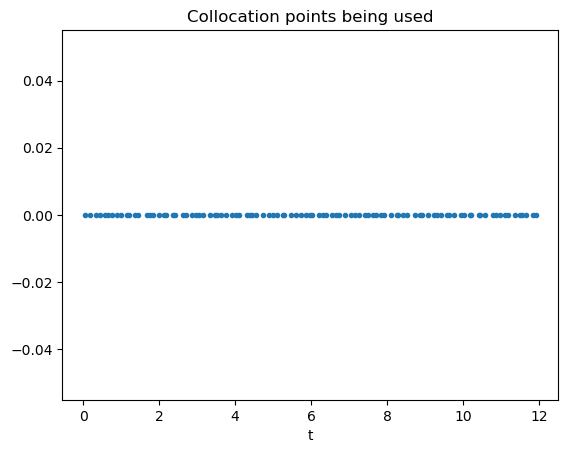

In [618]:
plt.plot(de_points[:,0], 0*de_points[:,0],'.')
plt.xlabel('t')
plt.title('Collocation points being used')

In [619]:
# The main training function
@tf.function
def train_network(odes, inits, model, gamma, epsilon, alpha):

    # DE collocation points
    t_de = odes[:,:1]

    # Initial value points
    t_init, x_init, y_init = inits[:1], inits[1:2], inits[2:]

    # Outer gradient for tuning network parameters
    with tf.GradientTape() as tape:

        # Inner gradient for derivatives of u wrt x and t
        with tf.GradientTape(persistent=True) as tape2:
            
            tape2.watch(t_de)
            #model(t_de, training=True)[0]
            #model(t_de, training=True)[1]
            [x, y] = model(t_de, training=True)
            

        # Derivative of the neural network solution
        xt = tape2.gradient(x, t_de)
        yt = tape2.gradient(y, t_de)
    
        yx = yt/xt
        xy = xt/yt
    
      
        # Define the differential equation loss  
        eqn1 = xt - (a*x - b*x*y)
        eqn2 = yt - (c*x*y - d*y)
        DEloss = tf.reduce_mean(tf.square(eqn1) + tf.square(eqn2))
                         
        # Define the initial value loss
        [x_init_pred, y_init_pred] = model(t_init, training=True)
        IVloss = tf.reduce_mean(tf.square(x_init_pred - x_init) + tf.square(y_init_pred - y_init))
    
    
        #Implicit integration loss
        v = (c * x) - (d * tf.math.log(x)) + (b * y) - (a * tf.math.log(y))
        Vloss = tf.math.reduce_mean(tf.square(tf.boolean_mask(v, tf.math.is_finite(v))) - v0)
        
        V = (c * model(t_de, training=True)[0]) - (d * tf.math.log(model(t_de, training=True)[0])) + (b * model(t_de, training=True)[1]) - (a * tf.math.log(model(t_de, training=True)[1]))
        tf.print(V)
        
        
    
        # Composite loss function
        loss = DEloss + gamma*IVloss + epsilon*Vloss

        grads = tape.gradient(loss, model.trainable_variables)
    
    return DEloss, IVloss, Vloss, grads

In [620]:
def PINNtrain(de_points, x0, y0, epochs, gamma_val, epsilon_val, alpha_val):

  # Total number of collocation points
  N_de = len(de_points)

  # Batch size
  bs_de = N_de//10

  # Weight factors
  gamma = gamma_val
  epsilon = epsilon_val
  alpha = alpha_val

  # Learning rate
  lr_model = 1e-3

  # Initial value
  t_init = np.array([t0]).astype(np.float32)
  x_init = np.array([x0]).astype(np.float32)
  y_init = np.array([y0]).astype(np.float32)

  epoch_loss = np.zeros(epochs)
  nr_batches = 0

  # Generate the tf.Dataset for the initial collocation points
  inits = np.column_stack([t_init, x_init, y_init])
  ds_init = tf.data.Dataset.from_tensor_slices(inits)
  ds_init = ds_init.cache()


  # Generate the tf.Dataset for the differential equations points
  ds_ode = tf.data.Dataset.from_tensor_slices(de_points.astype(np.float32))
  ds_ode = ds_ode.cache().shuffle(N_de).batch(bs_de)

  # Generate entire dataset
  ds = tf.data.Dataset.zip((ds_ode, ds_init))

  ds = ds.prefetch(tf.data.experimental.AUTOTUNE)

  # Generate the model
  opt = tf.keras.optimizers.Adam(lr_model)
  model = build_model() 

  # Main training loop
  for i in range(epochs):

    # Training for that epoch
    for (des, inits) in ds:

      # Train the network
      DEloss, IVloss, Vloss, grads = train_network(des, inits, model, gamma, epsilon, alpha)

      # Gradient step
      opt.apply_gradients(zip(grads, model.trainable_variables))
      
      epoch_loss[i] += DEloss + gamma*IVloss + epsilon*Vloss
      nr_batches = nr_batches + 1

    # Get total epoch loss
    epoch_loss[i] = epoch_loss[i]/nr_batches
    nr_batches = 0

    
    if (np.mod(i, 100)==0):
      print("DE loss, IV loss, Vloss in {}th epoch: {: 6.4f}, {: 6.4f}, {: 6.4f}.".format(i, DEloss, IVloss, Vloss))

  return epoch_loss, model

In [621]:
def train_plot(epochs, gamma, epsilon, alpha) :
    
    loss, model = PINNtrain(de_points, x0, y0, epochs, gamma, epsilon, alpha)
    
    # Grid where to evaluate the model
    step_size = 0.005
    t = np.arange(t0, tfinal, step_size)
    t = np.round(t, decimal_p)
    
    plt.figure(1)
    plt.plot(loss)

    # Model prediction
    [x, y] = model(t)
    
    # Plot the solution
    print(len(x))
    
    plt.figure(2)
    plt.plot(x, y, label = "e = " + str(epochs) + ", gamma = " + str(gamma) + ", epsilon = " + str(epsilon) + ", alpha = " + str(alpha))
    plt.legend(loc='best')
    plt.plot(xpoints, ypoints, color = 'black')
    
    error = calc_err(t, x, y)    
    
    plt.figure(3)
    print(epsilon, error)
    plt.scatter(epsilon, error)
    


In [622]:
def calc_err(t_preds, x_preds, y_preds) :
    
    error = 0
    
    for i in range(len(t_preds)) :
        
        t_i = np.where(tpoints == t_preds[i])
        
        err = np.abs(x_preds[i] - xpoints[t_i])  + np.abs(y_preds[i] - ypoints[t_i])
        
        error = error + err
        
    return error

In [623]:
start = time.time()

In [624]:
epochs = 1000


# for epsilon_val in np.arange(0, 1.2, 0.2, dtype=np.float32) :
    
#     train_plot(epochs, 1, epsilon_val)


train_plot(epochs, 1.2, 0.0001, 0.0)
#train_plot(epochs, 1.2, 0.0001, 0.000001)
#train_plot(epochs, 1.2, 1)

b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_318/Tanh:0', description="created by layer 'dense_318'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_319/Tanh:0', description="created by layer 'dense_319'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_320/Tanh:0', description="created by layer 'dense_320'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_321/Tanh:0', description="created by layer 'dense_321'")
[[-nan]
 [-nan]
 [-nan]
 ...
 [-nan]
 [-nan]
 [-nan]]
DE loss, IV loss, Vloss in 0th epoch:  0.1315,  2.5834,    nan.
[[6.75552177]
 [-nan]
 [-nan]
 ...
 [-nan]
 [-nan]
 [-nan]]
[[6.29009628]
 [-nan]
 [5.80285263]
 ...
 [-nan]
 [6.26507568]
 [-nan]]
[[-nan]
 [-nan]
 [-nan]
 ...
 [6.83808041]
 [4.82635689]
 [-nan]]
[[-nan]
 [3.13895035]
 [3.68137431]
 ...
 [3.24760818]
 [-nan]
 [3.95590162]

[[2.22889733]
 [2.23647475]
 [3.86723828]
 ...
 [2.24475193]
 [2.69659114]
 [2.30360317]]
[[4.5482378]
 [2.21959901]
 [2.24240828]
 ...
 [3.83824921]
 [2.21974301]
 [2.31217432]]
[[2.32838917]
 [2.24570656]
 [2.24699187]
 ...
 [2.2589767]
 [3.33482099]
 [3.24898577]]
[[2.20914364]
 [2.22006369]
 [3.6831708]
 ...
 [2.22025585]
 [3.06430101]
 [3.11531448]]
[[2.23100257]
 [2.21179557]
 [2.22859383]
 ...
 [-nan]
 [4.98703194]
 [2.21439719]]
[[2.20509338]
 [2.22831702]
 [6.6273632]
 ...
 [2.20765829]
 [2.21442628]
 [2.56604719]]
[[3.04821634]
 [2.31580257]
 [2.68588305]
 ...
 [2.22417903]
 [2.34133959]
 [2.23125505]]
DE loss, IV loss, Vloss in 100th epoch:  0.0448,  0.0050,  4.2280.
[[2.23078179]
 [2.22753763]
 [2.22564244]
 ...
 [-nan]
 [2.21000838]
 [2.22311068]]
[[2.98209429]
 [2.20853782]
 [2.20779371]
 ...
 [2.20116949]
 [2.4341352]
 [2.32626843]]
[[2.20742702]
 [2.22267842]
 [2.53052211]
 ...
 [2.19957614]
 [2.82458496]
 [2.2002759]]
[[3.20706081]
 [2.21772337]
 [4.91442871]
 ...
 [2.

KeyboardInterrupt: 

In [ ]:
end = time.time()

print((end-start)/60)

In [ ]:
#tfinal epoch first ~0,0 error

#5 4000
#7 8000
#7.5 10000
#8 20000

#0.0001 epsilon seems best
#~1.2 gamma

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

step = 0.001

# Make data.
x = np.arange(step, 3, step)
y = np.arange(step, 3, step)
x, y = np.meshgrid(x, y)

V_loss = (c * x) - (d * np.log(x)) + (b * y) - (a * np.log(y))

#V_loss = np.sqrt(x**2 + y**2)

z = np.abs(V_loss - v0)

# Plot the surface.

plt.plot(xpoints, ypoints, [-1]*len(xpoints), color = 'black')
surf = ax.plot_surface(x, y, z, cmap=cm.coolwarm, linewidth=0, antialiased=False)


ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

# Customize the z axis.
ax.set_zlim(-1, 5)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()